In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [130]:
#FINAL
df_anual = pd.read_csv("data/final/resumo_anual_pb.csv", sep=';')
df_mensal = pd.read_csv("data/final/resumo_mensal_pb.csv", sep=';')

#PROCESSADAS
df_ibge_proc = pd.read_csv("data/processed/ibge/populacao_uf_2015_2025.csv", sep=';')
df_sih_total = pd.read_csv("data/processed/sih/sih_pb_2015_2025_saude_mental.csv", sep=';')

#Crus
df_popmun_raw = pd.read_csv("data/raw/ibge/populacao_municipios_2015_2025.csv", sep=';')
df_geomap_01 = pd.read_csv("data/raw/trends/geoMap.csv", sep=',')
df_geomap_02 = pd.read_csv("data/raw/trends/geoMap(1).csv", sep=',')
df_trends = pd.read_csv("data/raw/trends/google_trends_brasil_2015_2025.csv", sep=',')
df_timeline1 = pd.read_csv("data/raw/trends/multiTimeline(1).csv", sep=',')
df_timeline1 = pd.read_csv("data/raw/trends/multiTimeline(2).csv", sep=',')



In [131]:
display(df_anual.head(10))

,ANO_CMPT,GRUPO_CID,internacoes,obitos,media_dias_internacao,valor_total
0,2015,Episódio depressivo,50,0,9.940000,24153.53
1,2015,Transtorno depressivo recorrente,23,0,17.652174,20577.69
2,2015,Transtornos ansiosos,4,0,19.250000,3677.89
3,2016,Episódio depressivo,64,0,9.437500,28599.77
4,2016,Transtorno depressivo recorrente,39,0,14.230769,27908.87
5,2016,Transtornos ansiosos,23,0,12.913043,15196.25
6,2017,Episódio depressivo,10,0,12.300000,6121.27
7,2017,Transtorno depressivo recorrente,10,0,12.800000,5866.54
8,2017,Transtornos ansiosos,1,0,11.000000,596.41
9,2018,Episódio depressivo,46,0,11.065217,27857.66


# HEAD do Resumo Anual na paraiba

In [132]:
#Verificando a passagem de tempo pelo número de internações
internacoes_por_ano = df_anual.groupby('ANO_CMPT')['internacoes'].sum().reset_index()
display(internacoes_por_ano)
#O objetivo era confirmar se o processo de resumo não tinha afetado o grafico
internacoes = df_sih_total.groupby('ANO_CMPT')['DIAS_PERM'].sum().reset_index()
display(internacoes)

,ANO_CMPT,internacoes
0,2015,77
1,2016,126
2,2017,21
3,2018,66
4,2019,40
5,2020,83
6,2021,21
7,2022,116
8,2023,65
9,2024,152


,ANO_CMPT,DIAS_PERM
0,2015,980
1,2016,1456
2,2017,262
3,2018,705
4,2019,348
5,2020,798
6,2021,128
7,2022,818
8,2023,314
9,2024,633


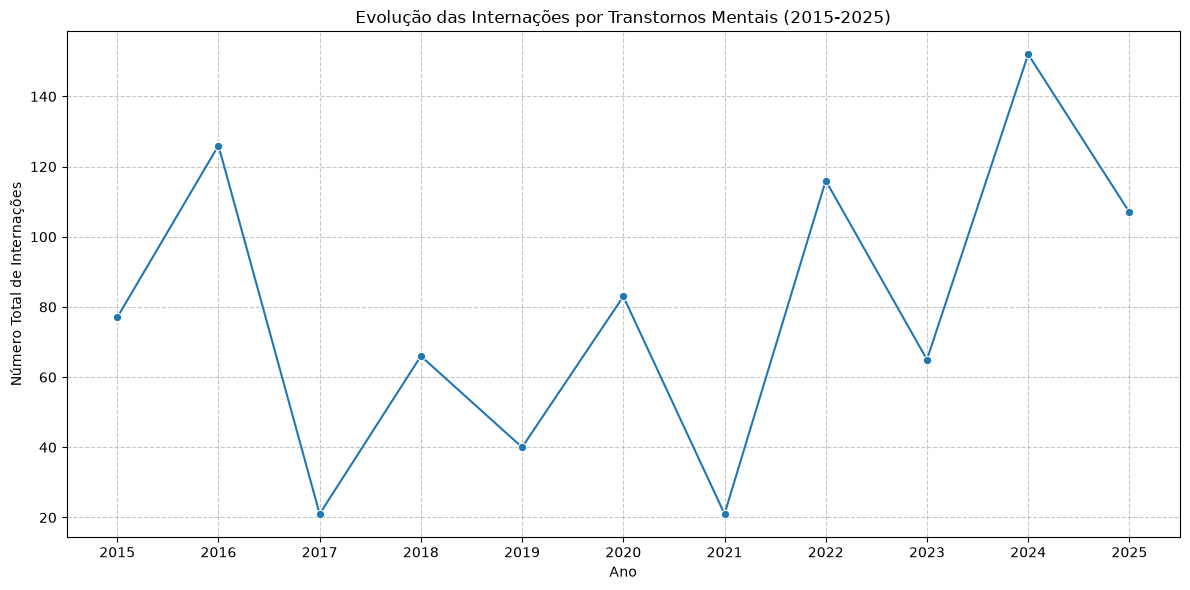

In [133]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='ANO_CMPT', y='internacoes', data=internacoes_por_ano, marker='o')
plt.title('Evolução das Internações por Transtornos Mentais (2015-2025)')
plt.xlabel('Ano')
plt.ylabel('Número Total de Internações')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(internacoes_por_ano['ANO_CMPT'])
plt.tight_layout()
plt.show()

# Custos

,ANO_CMPT,valor_total,internacoes,custo_medio
0,2015,48409.11,77,628.689740
1,2016,71704.89,126,569.086429
2,2017,12584.22,21,599.248571
3,2018,41047.41,66,621.930455
4,2019,16754.52,40,418.863000
5,2020,50557.12,83,609.121928
6,2021,9109.51,21,433.786190
7,2022,42940.88,116,370.180000
8,2023,9984.86,65,153.613231
9,2024,22535.45,152,148.259539


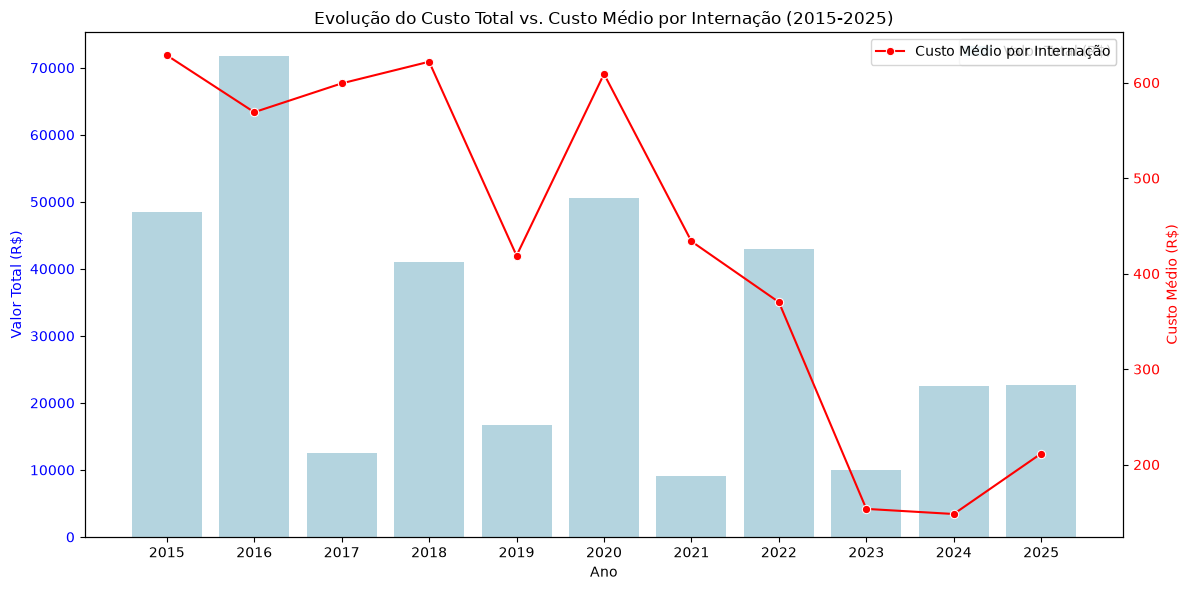

C:\Users\Ricardo\AppData\Local\Temp\ipykernel_5336\3087018113.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ANO_CMPT', y='media_dias_internacao', data=dias_anuais, palette='viridis')


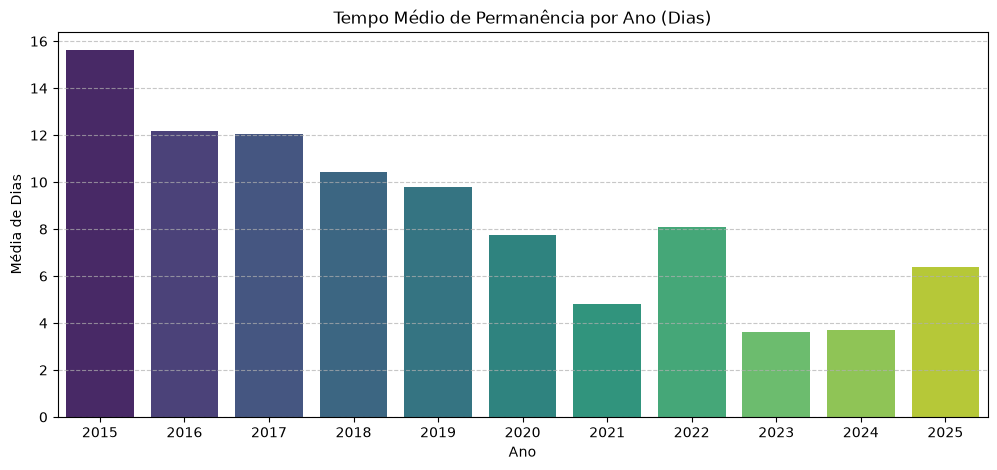

In [134]:

custos_anuais = df_anual.groupby('ANO_CMPT').agg({
    'valor_total': 'sum',
    'internacoes': 'sum'
}).reset_index()

custos_anuais['custo_medio'] = custos_anuais['valor_total'] / custos_anuais['internacoes']

display(custos_anuais)
display()

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(x='ANO_CMPT', y='valor_total', data=custos_anuais, ax=ax1, color='lightblue', label='Valor Total (R$)')
ax1.set_ylabel('Valor Total (R$)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
sns.lineplot(x=range(len(custos_anuais)), y='custo_medio', data=custos_anuais, ax=ax2, marker='o', color='red', label='Custo Médio por Internação')
ax2.set_ylabel('Custo Médio (R$)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Evolução do Custo Total vs. Custo Médio por Internação (2015-2025)')
ax1.set_xlabel('Ano')
fig.tight_layout()
plt.show()

dias_anuais = df_anual.groupby('ANO_CMPT')['media_dias_internacao'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(x='ANO_CMPT', y='media_dias_internacao', data=dias_anuais, palette='viridis')
plt.title('Tempo Médio de Permanência por Ano (Dias)')
plt.xlabel('Ano')
plt.ylabel('Média de Dias')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Fonte da idade: a coluna IDADE já vem no arquivo carregado em df_sih_total.

Casos por grupo CID e ano:
 ANO_CMPT                        GRUPO_CID  total
     2015              Episódio depressivo     50
     2015 Transtorno depressivo recorrente     23
     2015             Transtornos ansiosos      4
     2016              Episódio depressivo     64
     2016 Transtorno depressivo recorrente     39
     2016             Transtornos ansiosos     23
     2017              Episódio depressivo     10
     2017 Transtorno depressivo recorrente     10
     2017             Transtornos ansiosos      1
     2018              Episódio depressivo     46
     2018 Transtorno depressivo recorrente     20
     2019              Episódio depressivo     31
     2019 Transtorno depressivo recorrente      7
     2019             Transtornos ansiosos      2
     2020              Episódio depressivo     63
     2020 Transtorno depressivo recorrente     18
     2020             Transtornos ansiosos    

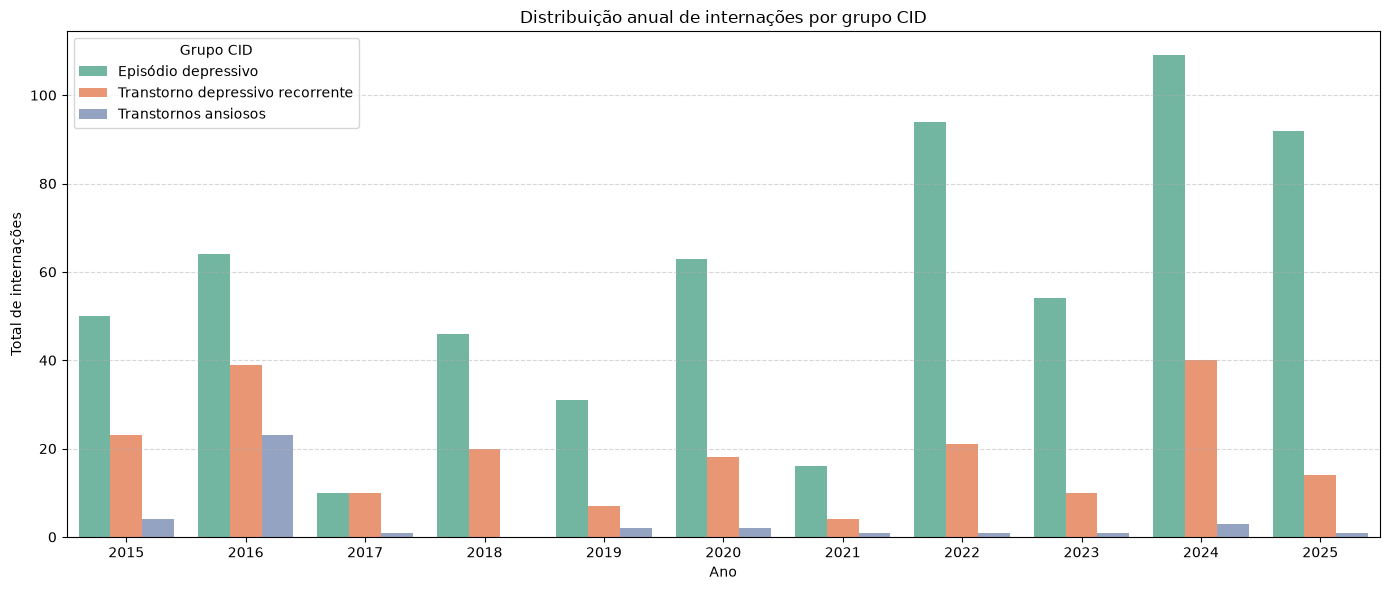

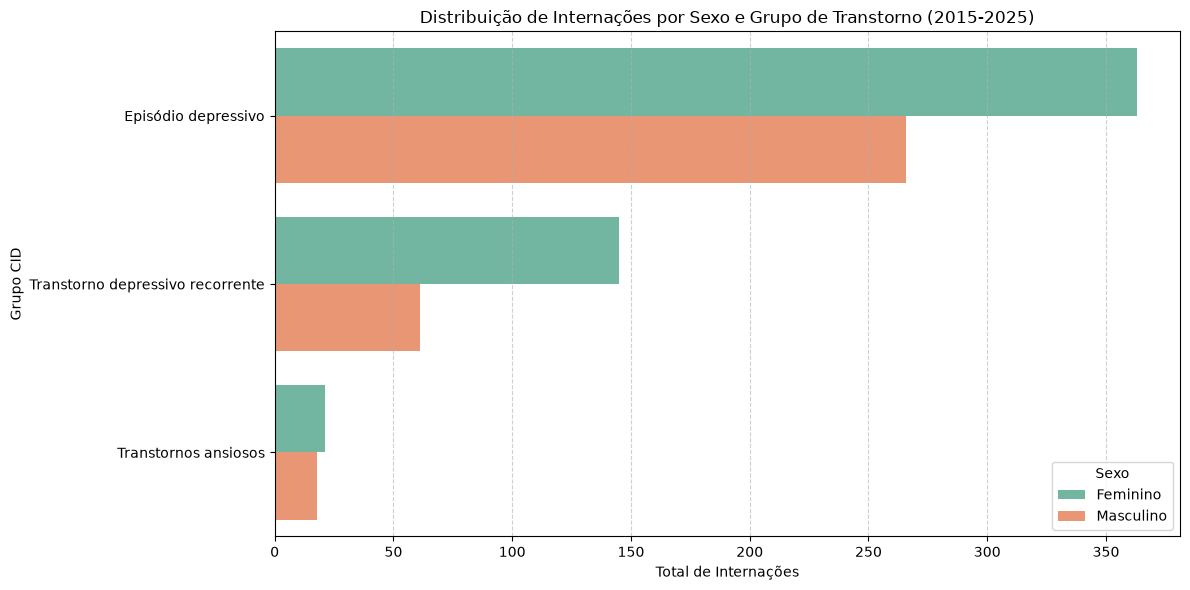

In [135]:
def mapear_cid(cid):
    if str(cid).startswith('F32'): return 'Episódio depressivo'
    if str(cid).startswith('F33'): return 'Transtorno depressivo recorrente'
    if str(cid).startswith(('F40', 'F41')): return 'Transtornos ansiosos'
    return 'Outros'

df_sih_total['GRUPO_CID'] = df_sih_total['DIAG_PRINC'].apply(mapear_cid)

df_sexo = df_sih_total[df_sih_total['GRUPO_CID'] != 'Outros'].copy()

df_sexo['SEXO_LABEL'] = df_sexo['SEXO'].map({1: 'Masculino', 3: 'Feminino', 2: 'Outro', '1': 'Masculino', '3': 'Feminino', '2': 'Outro'})

sexo_cid = df_sexo.groupby(['SEXO_LABEL', 'GRUPO_CID']).size().reset_index(name='total')
contagem_por_ano = (
    df_sih_total[df_sih_total['GRUPO_CID'] != 'Outros']
    .groupby(['ANO_CMPT', 'GRUPO_CID'])
    .size()
    .reset_index(name='total')
)

print('Fonte da idade: a coluna IDADE já vem no arquivo carregado em df_sih_total.')
print('\nCasos por grupo CID e ano:')
print(contagem_por_ano.to_string(index=False))
print('\nCasos por grupo CID (total):')
print(df_sih_total['GRUPO_CID'].value_counts().to_string())

plt.figure(figsize=(14, 6))
sns.barplot(data=contagem_por_ano, x='ANO_CMPT', y='total', hue='GRUPO_CID', palette='Set2')
plt.title('Distribuição anual de internações por grupo CID')
plt.xlabel('Ano')
plt.ylabel('Total de internações')
plt.legend(title='Grupo CID')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='total', y='GRUPO_CID', hue='SEXO_LABEL', data=sexo_cid, palette='Set2')
plt.title('Distribuição de Internações por Sexo e Grupo de Transtorno (2015-2025)')
plt.xlabel('Total de Internações')
plt.ylabel('Grupo CID')
plt.legend(title='Sexo')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [136]:
df_completo['IDADE'] = pd.to_numeric(df_completo['IDADE'], errors='coerce')

df_idade_limpo = df_completo.dropna(subset=['IDADE'])

perfil_etario = df_idade_limpo[df_idade_limpo['GRUPO_CID'] != 'Outros'].groupby(['ANO_CMPT', 'GRUPO_CID'])['IDADE'].mean().reset_index()

Observações removidas por pouca amostra:
Empty DataFrame
Columns: [ANO_CMPT, GRUPO_CID, n]
Index: []


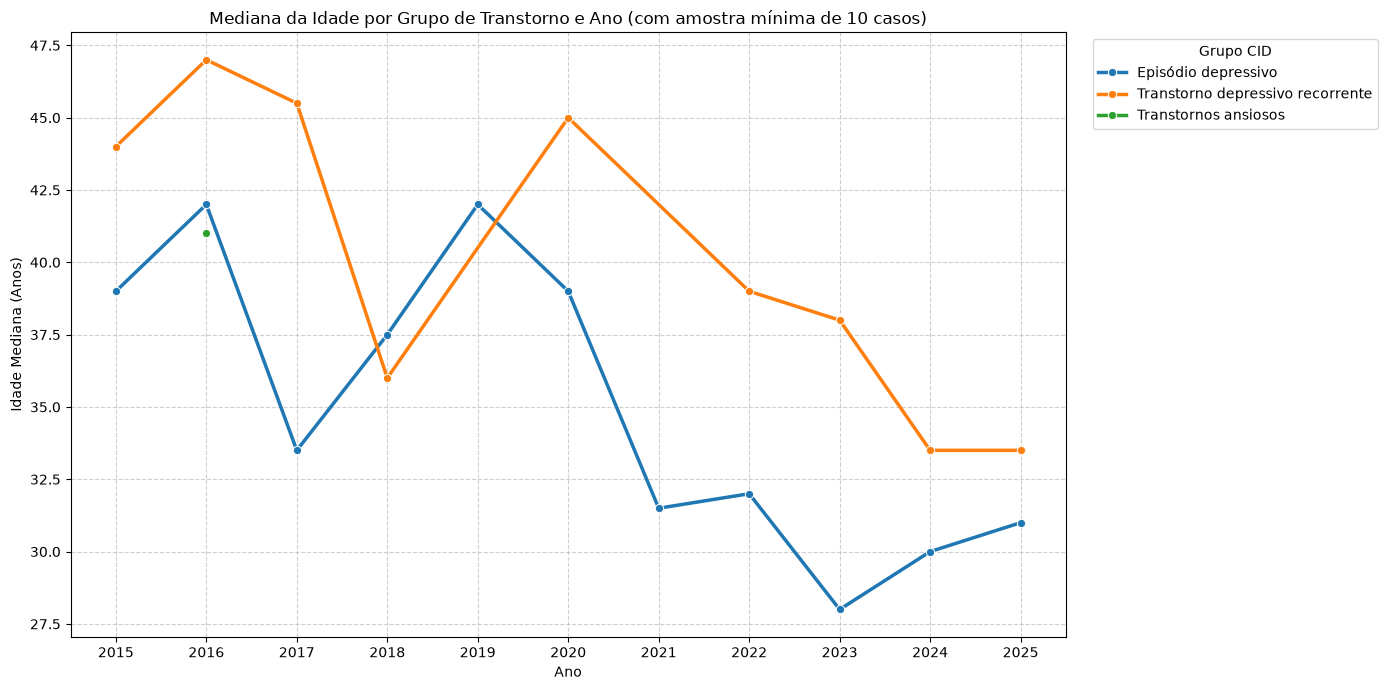

In [137]:
df_completo['IDADE'] = pd.to_numeric(df_completo['IDADE'], errors='coerce')

df_idade_limpo = df_completo.dropna(subset=['IDADE'])

perfil_etario = (
    df_idade_limpo[df_idade_limpo['GRUPO_CID'] != 'Outros']
    .groupby(['ANO_CMPT', 'GRUPO_CID'])['IDADE']
    .agg(['count', 'median', 'mean'])
    .reset_index()
    .rename(columns={'count': 'n', 'median': 'idade_mediana', 'mean': 'idade_media'})
)

# Mantém apenas séries com amostra razoável para evitar interpretação baseada em poucos casos
perfil_etario = perfil_etario[perfil_etario['n'] >= 10]

print('Observações removidas por pouca amostra:')
print(perfil_etario[perfil_etario['n'] < 10][['ANO_CMPT', 'GRUPO_CID', 'n']].to_string(index=False))

plt.figure(figsize=(14, 7))
sns.lineplot(data=perfil_etario, x='ANO_CMPT', y='idade_mediana', hue='GRUPO_CID', marker='o', linewidth=2.5)

plt.title('Mediana da Idade por Grupo de Transtorno e Ano (com amostra mínima de 10 casos)')
plt.xlabel('Ano')
plt.ylabel('Idade Mediana (Anos)')
plt.legend(title='Grupo CID', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(perfil_etario['ANO_CMPT'].unique())
plt.tight_layout()
plt.show()

In [138]:
df_completo['MESMO_MUNICIPIO'] = df_completo['MUNIC_RES'] == df_completo['MUNIC_MOV']

fluxo_anual = df_completo.groupby(['ANO_CMPT', 'MESMO_MUNICIPIO']).size().unstack(fill_value=0)
fluxo_anual_percent = fluxo_anual.div(fluxo_anual.sum(axis=1), axis=0) * 100


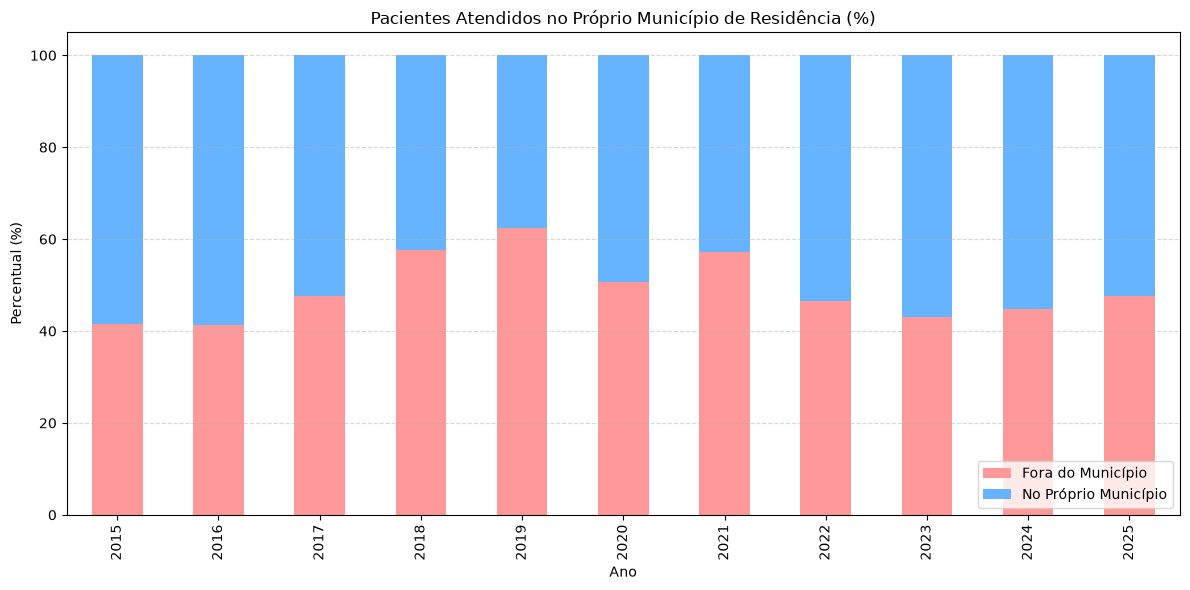

In [139]:

plt.figure(figsize=(12, 6))
fluxo_anual_percent.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#ff9999','#66b3ff'])

plt.title('Pacientes Atendidos no Próprio Município de Residência (%)')
plt.xlabel('Ano')
plt.ylabel('Percentual (%)')
plt.legend(['Fora do Município', 'No Próprio Município'], loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

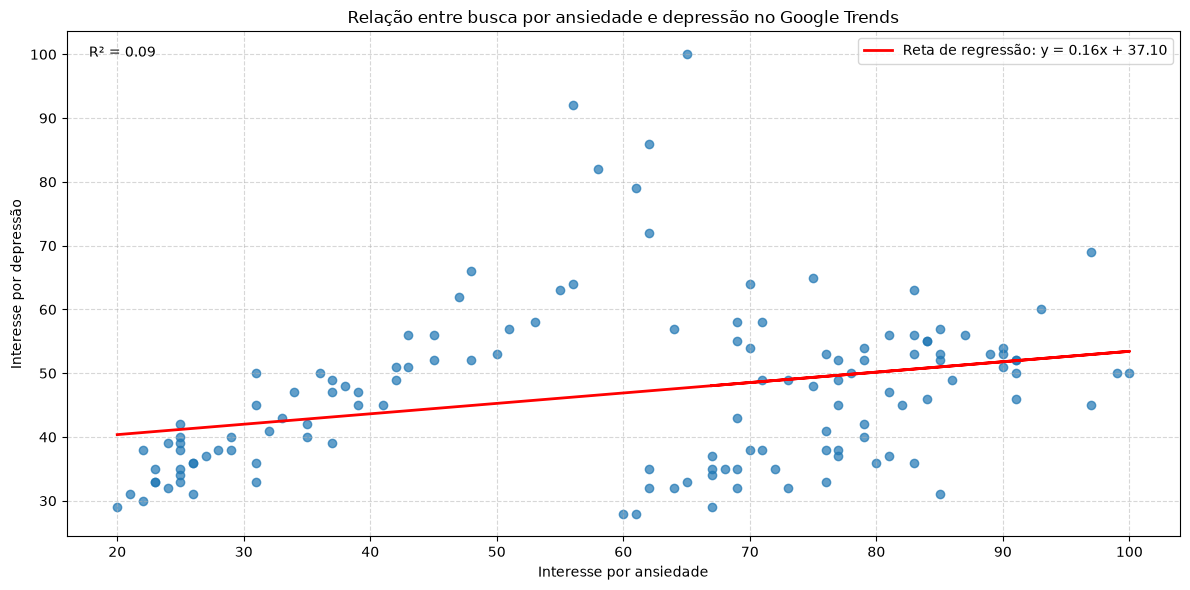

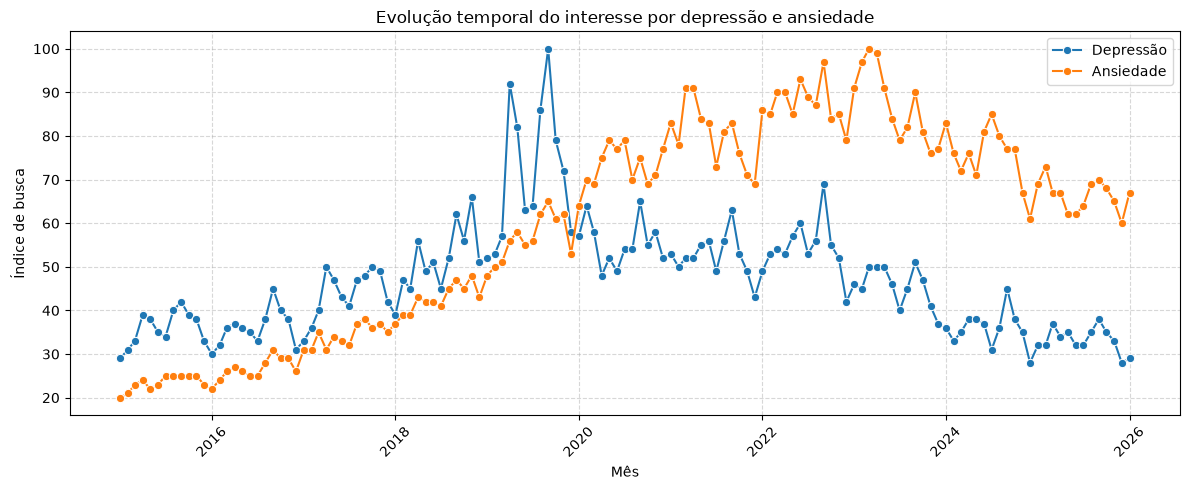

In [140]:
from pathlib import Path

# Leitura dos dados de Google Trends para depressão e ansiedade
trends_depressao = pd.read_csv("data/raw/trends/google_trends_brasil_2015_2025.csv", sep=',')
trends_ansiedade = pd.read_csv("data/raw/trends/multiTimeline(1).csv", sep=',')


def preparar_series(df, nome_coluna):
    df = df.copy()
    df.index = pd.Index(df.index)
    if str(df.index[0]).startswith('Mês'):
        df = df.iloc[1:].copy()
        df.index = pd.to_datetime(df.index, format='%Y-%m')
    else:
        df.index = pd.to_datetime(df.index, format='%Y-%m')
    df = df.rename(columns={df.columns[0]: nome_coluna})
    df[nome_coluna] = pd.to_numeric(df[nome_coluna], errors='coerce')
    return df.dropna()


depressao_df = preparar_series(trends_depressao, 'depressao')
ansiedade_df = preparar_series(trends_ansiedade, 'ansiedade')

trends = depressao_df.join(ansiedade_df, how='inner').sort_index()
trends = trends.reset_index().rename(columns={'index': 'mes'})

# Regressão linear simples: ansiedade -> depressão
x = trends['ansiedade'].to_numpy()
y = trends['depressao'].to_numpy()
coef = np.polyfit(x, y, 1)
a, b = coef
pred = a * x + b
r2 = 1 - np.sum((y - pred) ** 2) / np.sum((y - y.mean()) ** 2)

plt.figure(figsize=(12, 6))
plt.scatter(trends['ansiedade'], trends['depressao'], alpha=0.7, color='#1f77b4')
plt.plot(x, pred, color='red', linewidth=2, label=f'Reta de regressão: y = {a:.2f}x + {b:.2f}')
plt.title('Relação entre busca por ansiedade e depressão no Google Trends')
plt.xlabel('Interesse por ansiedade')
plt.ylabel('Interesse por depressão')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.text(0.02, 0.95, f'R² = {r2:.2f}', transform=plt.gca().transAxes)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.lineplot(data=trends, x='mes', y='depressao', label='Depressão', marker='o')
sns.lineplot(data=trends, x='mes', y='ansiedade', label='Ansiedade', marker='o')
plt.title('Evolução temporal do interesse por depressão e ansiedade')
plt.xlabel('Mês')
plt.ylabel('Índice de busca')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()